<a href="https://colab.research.google.com/github/theochi/MachineLearning/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

path = kagglehub.dataset_download(
    "dnkumars/cybersecurity-intrusion-detection-dataset"
)

csv_files = list(Path(path).rglob("*.csv"))

print("Available CSV files:")
for file in csv_files:
    print(file)

df = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)

100%|██████████| 261k/261k [00:00<00:00, 53.1MB/s]

Extracting files...
Available CSV files:
/root/.cache/kagglehub/datasets/dnkumars/cybersecurity-intrusion-detection-dataset/versions/2/cybersecurity_intrusion_data.csv

Dataset loaded successfully.
Dataset shape: (9537, 11)


In [3]:
df.head()
df.info()
df.describe()
df.describe(include="all").T

inspection_columns = [
    "network_packet_size",
    "session_duration",
    "login_attempts",
    "protocol_type",
    "browser_type"
]

df[inspection_columns].describe(include="all").T

df = df.drop(columns=["session_id"], errors="ignore")

print("Columns after dropping the identifier:")
print(df.columns.tolist())

missing_summary = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB
Columns after dropping the identifier:
['network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'b

,Missing Values,Missing Percentage
encryption_used,1966,20.61
network_packet_size,0,0.00
protocol_type,0,0.00
login_attempts,0,0.00
session_duration,0,0.00
ip_reputation_score,0,0.00
failed_logins,0,0.00
browser_type,0,0.00
unusual_time_access,0,0.00
attack_detected,0,0.00


In [4]:
target = "attack_detected"

# Remove records where the target itself is missing
df_clean = df.dropna(subset=[target]).copy()

X = df_clean.drop(columns=[target])
y = df_clean[target].astype(int)

print("Feature-data shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

preprocessing_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

X_processed = preprocessing_pipeline.fit_transform(X)

print("Original feature-data shape:", X.shape)
print("Processed feature-data shape:", X_processed.shape)

Feature-data shape: (9537, 9)
Target shape: (9537,)

Target distribution:
attack_detected
0    5273
1    4264
Name: count, dtype: int64
Numerical features:
['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']

Categorical features:
['protocol_type', 'encryption_used', 'browser_type']
Original feature-data shape: (9537, 9)
Processed feature-data shape: (9537, 16)


In [5]:
feature_names = (
    preprocessing_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

processed_df = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed,
    columns=feature_names
)

processed_df.head()

numeric_imputer = SimpleImputer(strategy="median")

numeric_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(df_clean[numerical_features]),
    columns=numerical_features,
    index=df_clean.index
)

# Add the target variable
correlation_data = numeric_imputed.copy()
correlation_data[target] = df_clean[target]

correlation_matrix = correlation_data.corr(method="pearson")

correlation_matrix

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.006131,0.363726
unusual_time_access,-0.001255,0.007349,0.012930,-0.003146,0.006131,1.000000,0.008652
attack_detected,-0.006798,0.277320,0.041602,0.211540,0.363726,0.008652,1.000000


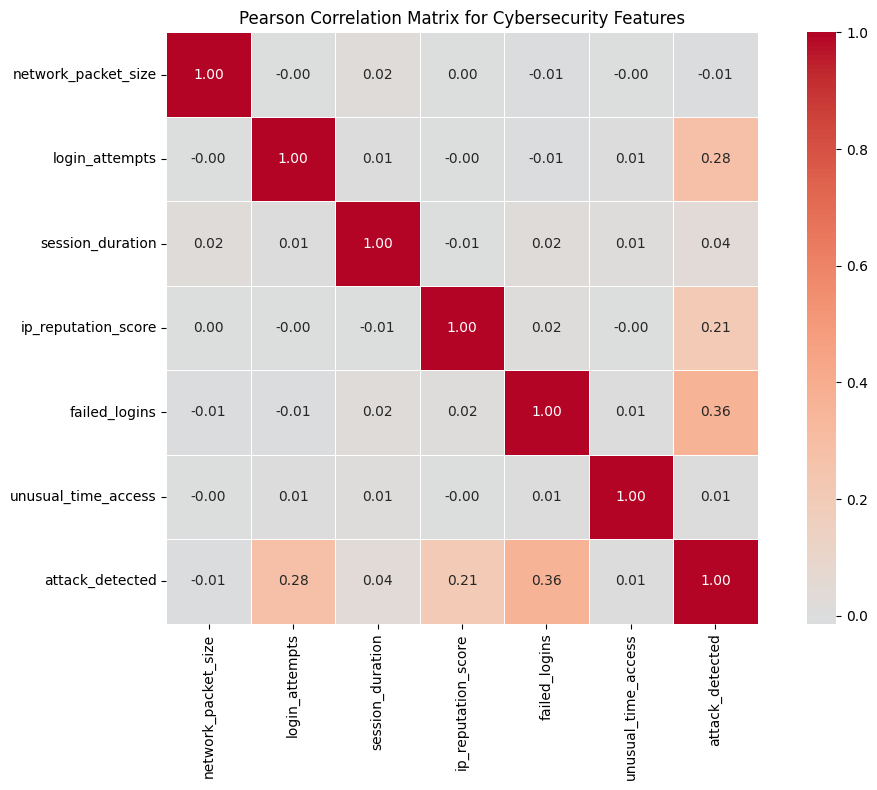

Features ranked by absolute correlation with attack_detected:
failed_logins          0.363726
login_attempts         0.277320
ip_reputation_score    0.211540
session_duration       0.041602
unusual_time_access    0.008652
network_packet_size   -0.006798
Name: attack_detected, dtype: float64
Randomly selected feature pairs:
[('ip_reputation_score', 'login_attempts'), ('network_packet_size', 'session_duration')]


In [6]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Matrix for Cybersecurity Features")
plt.tight_layout()
plt.show()

target_correlations = (
    correlation_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

print("Features ranked by absolute correlation with attack_detected:")
print(target_correlations)

import random

candidate_pairs = [
    ("network_packet_size", "session_duration"),
    ("network_packet_size", "ip_reputation_score"),
    ("session_duration", "ip_reputation_score"),
    ("login_attempts", "network_packet_size"),
    ("failed_logins", "session_duration"),
    ("ip_reputation_score", "login_attempts")
]

random_generator = random.Random(42)
selected_pairs = random_generator.sample(candidate_pairs, 2)

print("Randomly selected feature pairs:")
print(selected_pairs)

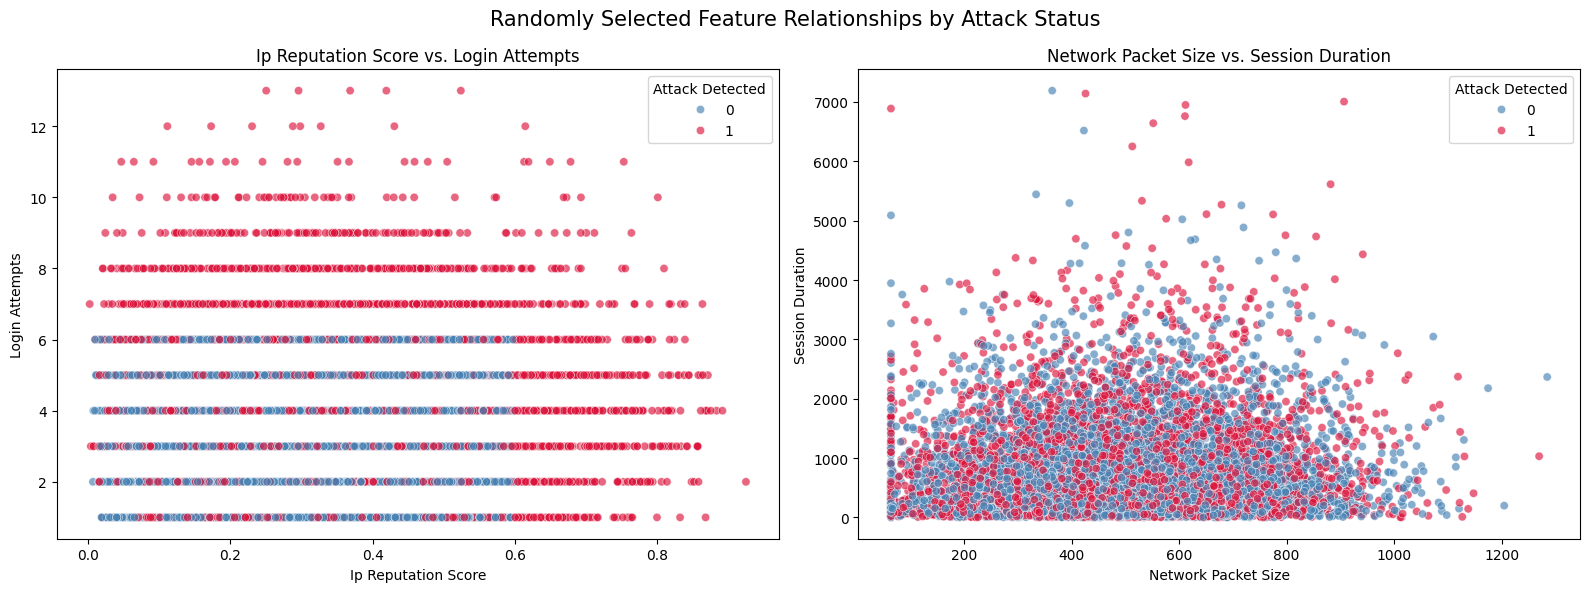

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for axis, (x_feature, y_feature) in zip(axes, selected_pairs):
    sns.scatterplot(
        data=df_clean,
        x=x_feature,
        y=y_feature,
        hue=target,
        palette={0: "steelblue", 1: "crimson"},
        alpha=0.65,
        ax=axis
    )

    axis.set_title(
        f"{x_feature.replace('_', ' ').title()} vs. "
        f"{y_feature.replace('_', ' ').title()}"
    )
    axis.set_xlabel(x_feature.replace("_", " ").title())
    axis.set_ylabel(y_feature.replace("_", " ").title())
    axis.legend(title="Attack Detected")

plt.suptitle(
    "Randomly Selected Feature Relationships by Attack Status",
    fontsize=15
)
plt.tight_layout()
plt.show()